### Phase 4: Backtesting-Strategie
Wir plotten zunächst die Regime-Wahrscheinlichkeiten der Modelle sowie der tatsächlichen Modell-Signale.

Anschließend testen wir den Erfolg einer Investition in Abhängigkeit zum gewählten Modell und den unten beschriebenen Regeln.

*   **Regel:**
    *   Wenn Modell sagt "Bull": 100% Aktien (S&P 500).
    *   Wenn Modell sagt "Bear": 100% Bonds oder Cash.
*   **Transaktionskosten:** Integriere realistische Kosten (z.B. 0,1% pro Trade), da ML-Modelle oft zu nervös hin- und herschalten ("Churning").

In [1]:
import pandas as pd

# Daten aus dem data-Ordner laden
test_df = pd.read_parquet("../data/03_test_df_data.parquet")

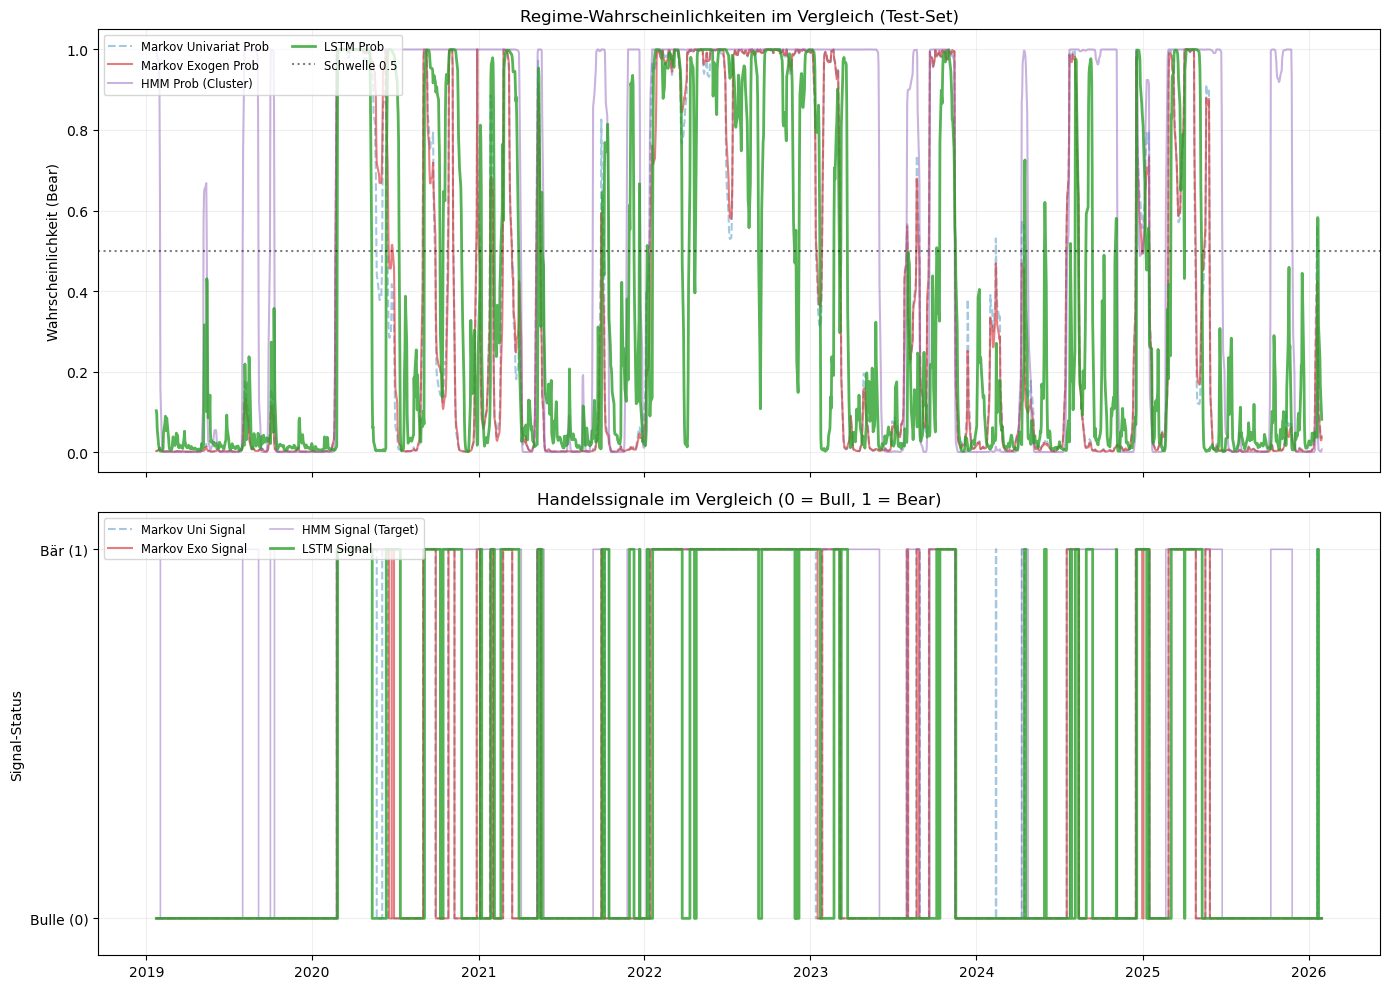

In [2]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# --- Plot 1: Wahrscheinlichkeiten (Probabilities) ---
# Markov Univariat (Blau)
ax1.plot(test_df.index, test_df['MS_Univariate_Prob_Bear'], 
         label='Markov Univariat Prob', alpha=0.4, color='tab:blue', linestyle='--')

# Markov Exogen (Rot)
ax1.plot(test_df.index, test_df['MS_Exo_Prob_Bear'], 
         label='Markov Exogen Prob', alpha=0.6, color='tab:red')

# HMM (Lila)
ax1.plot(test_df.index, test_df['HMM_Prob_Bear'], 
         label='HMM Prob (Cluster)', alpha=0.5, color='tab:purple')

# LSTM (Grün)
ax1.plot(test_df.index, test_df['LSTM_Prob_Bear'], 
         label='LSTM Prob', alpha=0.8, color='tab:green', linewidth=2)

ax1.axhline(y=0.5, color='black', linestyle=':', alpha=0.5, label='Schwelle 0.5')
ax1.set_title("Regime-Wahrscheinlichkeiten im Vergleich (Test-Set)")
ax1.set_ylabel("Wahrscheinlichkeit (Bear)")
ax1.legend(loc='upper left', fontsize='small', ncol=2)
ax1.grid(alpha=0.2)
ax1.set_ylim(-0.05, 1.05)

# --- Plot 2: Binäne Signale (0 oder 1) ---
ax2.step(test_df.index, test_df['MS_Univariate_Signal'], 
         where='post', label='Markov Uni Signal', alpha=0.4, color='tab:blue', linestyle='--')

ax2.step(test_df.index, test_df['MS_Exo_Signal'], 
         where='post', label='Markov Exo Signal', alpha=0.6, color='tab:red')

# HMM (Lila)
ax2.step(test_df.index, test_df['HMM_Regime'], 
         where='post', label='HMM Signal (Target)', alpha=0.5, color='tab:purple', linewidth=1.2)

ax2.step(test_df.index, test_df['LSTM_Signal'], 
         where='post', label='LSTM Signal', alpha=0.8, color='tab:green', linewidth=2)

ax2.set_title("Handelssignale im Vergleich (0 = Bull, 1 = Bear)")
ax2.set_ylabel("Signal-Status")
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Bulle (0)', 'Bär (1)'])
ax2.legend(loc='upper left', fontsize='small', ncol=2)
ax2.grid(alpha=0.2)
ax2.set_ylim(-0.1, 1.1)

# Layout optimieren
plt.tight_layout()
# Equity Curve persistieren
plt.savefig('../assets/regime_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

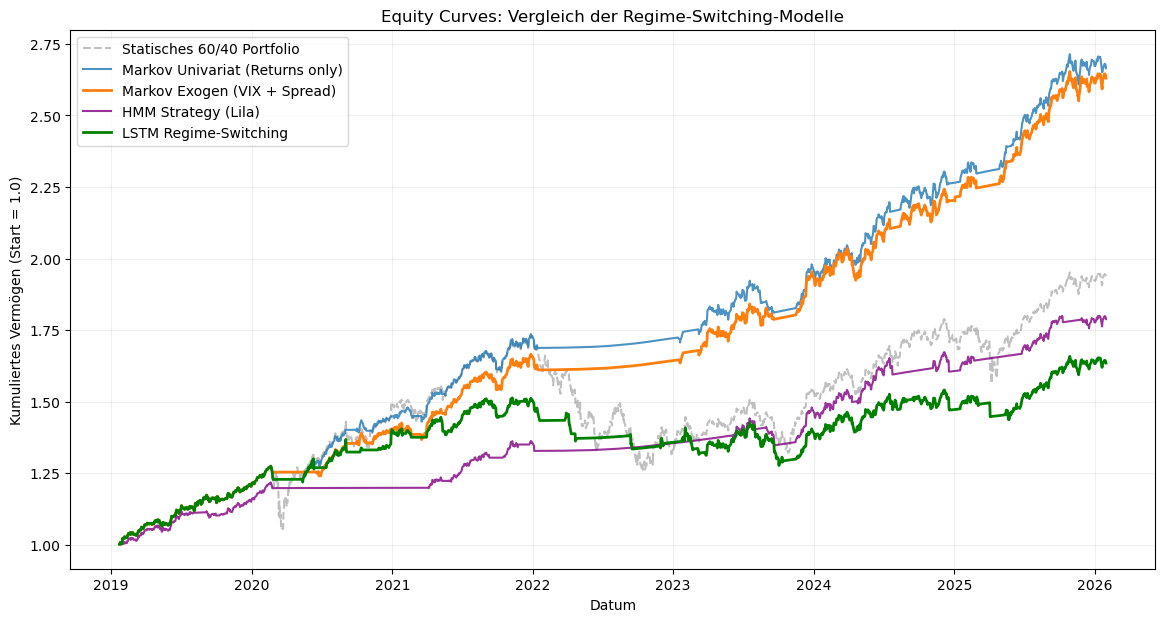


--- Finale Performance-Kennzahlen (Test-Zeitraum) ---
Buy_Hold            : 1.9344 (+93.44%)
MS_Univariate       : 2.6651 (+166.51%)
MS_Exogenous        : 2.6302 (+163.02%)
LSTM_Regime         : 1.6346 (+63.46%)
HMM_Based           : 1.7881 (+78.81%)

--- Maximum Drawdown Vergleich ---
Buy_Hold            : -27.10%
MS_Univariate       : -5.80%
MS_Exogenous        : -5.44%
LSTM_Regime         : -15.63%
HMM_Based           : -6.53%


In [3]:
# --- 5. Erweitertes Backtesting (Vergleich aller Strategien) ---

import numpy as np

def backtest(df, signal_col):
    """
    Berechnet die kumulierte Rendite einer Strategie.
    Bull (0): Investiert im 60/40 Portfolio
    Bear (1): Investiert im Geldmarkt (Cash_Returns)
    """
    # WICHTIG: Signal um 1 Tag verschieben! 
    # Wir handeln HEUTE basierend auf dem Signal, das GESTERN ABEND vorlag.
    trading_signal = df[signal_col].shift(1).fillna(0)
    
    # Logik: Wenn Signal 0 -> Portfolio-Return, sonst Cash-Return
    strategy_returns = np.where(trading_signal == 0, 
                                df['Returns'], 
                                df['Cash_Returns'])
    
    # Kumulierte Rendite berechnen (Startwert 1.0)
    return (1 + strategy_returns).cumprod()

# Ergebnisse in ein neues DataFrame für den Vergleich schreiben
backtesting_results = pd.DataFrame(index=test_df.index)

# 1. Benchmark: Statisches Buy & Hold (60% Aktien / 40% Anleihen)
backtesting_results['Buy_Hold'] = (1 + test_df['Returns']).cumprod()

# 2. Strategie: Markov Univariat (Nur basierend auf Rendite-Statistik)
backtesting_results['MS_Univariate'] = backtest(test_df, 'MS_Univariate_Signal')

# 3. Strategie: Markov Exogen (Inklusive VIX & Yield Spread)
backtesting_results['MS_Exogenous'] = backtest(test_df, 'MS_Exo_Signal')

# 4. Strategie: LSTM-Regime (Deep Learning Vorhersage)
backtesting_results['LSTM_Regime'] = backtest(test_df, 'LSTM_Signal')

# 5. Strategie: HMM-Regime
backtesting_results['HMM_Based'] = backtest(test_df, 'HMM_Regime')

# --- Visualisierung ---
plt.figure(figsize=(14, 7))

# Buy & Hold als graue Basislinie
plt.plot(backtesting_results['Buy_Hold'], label='Statisches 60/40 Portfolio', color='gray', alpha=0.5, linestyle='--')

# Die aktiven Strategien
plt.plot(backtesting_results['MS_Univariate'], label='Markov Univariat (Returns only)', alpha=0.8)
plt.plot(backtesting_results['MS_Exogenous'], label='Markov Exogen (VIX + Spread)', linewidth=2)
plt.plot(backtesting_results['HMM_Based'], label='HMM Strategy (Lila)', color='purple', linewidth=1.5, alpha=0.8)
plt.plot(backtesting_results['LSTM_Regime'], label='LSTM Regime-Switching', linewidth=2, color='green')

plt.title("Equity Curves: Vergleich der Regime-Switching-Modelle")
plt.xlabel("Datum")
plt.ylabel("Kumuliertes Vermögen (Start = 1.0)")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
# Equity Curve persistieren
plt.savefig('../assets/equity_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Performance Auswertung ---
print("\n--- Finale Performance-Kennzahlen (Test-Zeitraum) ---")
final_wealth = backtesting_results.iloc[-1]
for strategy, wealth in final_wealth.items():
    total_return = (wealth - 1) * 100
    print(f"{strategy:20s}: {wealth:.4f} ({total_return:+.2f}%)")

# Optional: Kurze Berechnung des Max Drawdowns für den schnellen Check
def calc_max_drawdown(series):
    roll_max = series.cummax()
    drawdown = series / roll_max - 1.0
    return drawdown.min()

print("\n--- Maximum Drawdown Vergleich ---")
for col in backtesting_results.columns:
    mdd = calc_max_drawdown(backtesting_results[col])
    print(f"{col:20s}: {mdd:.2%}")

# --- Wir erhalten in diesem Schritt neben df und test_df backtesting_results_df mit kumulierten Werten ---

In [4]:
output_path = "../data/04_backtesting_results_data.parquet"

# Speichern als Parquet
backtesting_results.to_parquet(output_path)

print(f"Dataframe erfolgreich unter {output_path} gespeichert.")

Dataframe erfolgreich unter ../data/04_backtesting_results_data.parquet gespeichert.
